In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import nnx

import jaxpm
from jaxpm import camels, training, plotting, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.nn import ConditionedCNN

print(jax.default_backend())

gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

mesh_shape = [mesh_per_dim] * 3

# with_latent = True
with_latent = False

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "Astrid"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    # "CV_0",
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

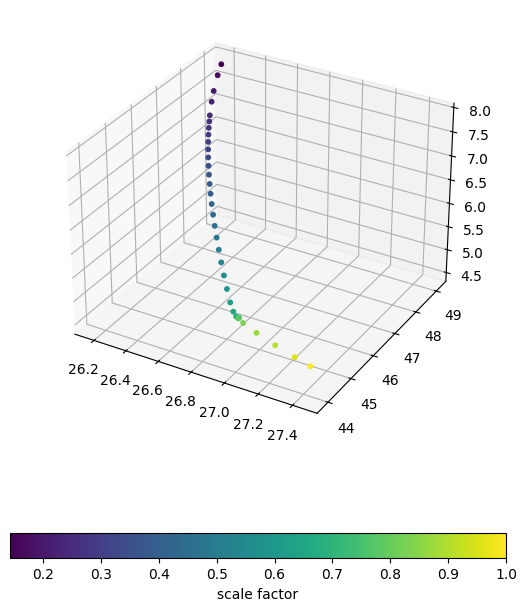

In [6]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

i_rand = np.random.choice(np.arange(parts_per_dim**3))
poss = gas_poss
# poss = dm_poss
X = poss[:, i_rand, 0]
Y = poss[:, i_rand, 1]
Z = poss[:, i_rand, 2]

im = ax.scatter(X, Y, Z, c=scales, cmap="viridis", marker="o", alpha=1, s=10)
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, aspect=20, label="scale factor")

# JaxPM

In [13]:
pressure_model = ConditionedCNN(
    d_in=4,
    d_out=1,
    d_hidden=16,
    n_hidden=8,
    kernel_size=(3, 3, 3),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    use_residual=True,
)

checkpoint_file = "/global/u2/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/pressure_code=SIMBA,parts=64,mesh=64_cnn_default_v1.jx"
pressure_model.load(checkpoint_file)

Checkpoint loaded from /global/u2/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/pressure_code=SIMBA,parts=64,mesh=64_cnn_default_v1.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:09<00:00,  2.46s/it]


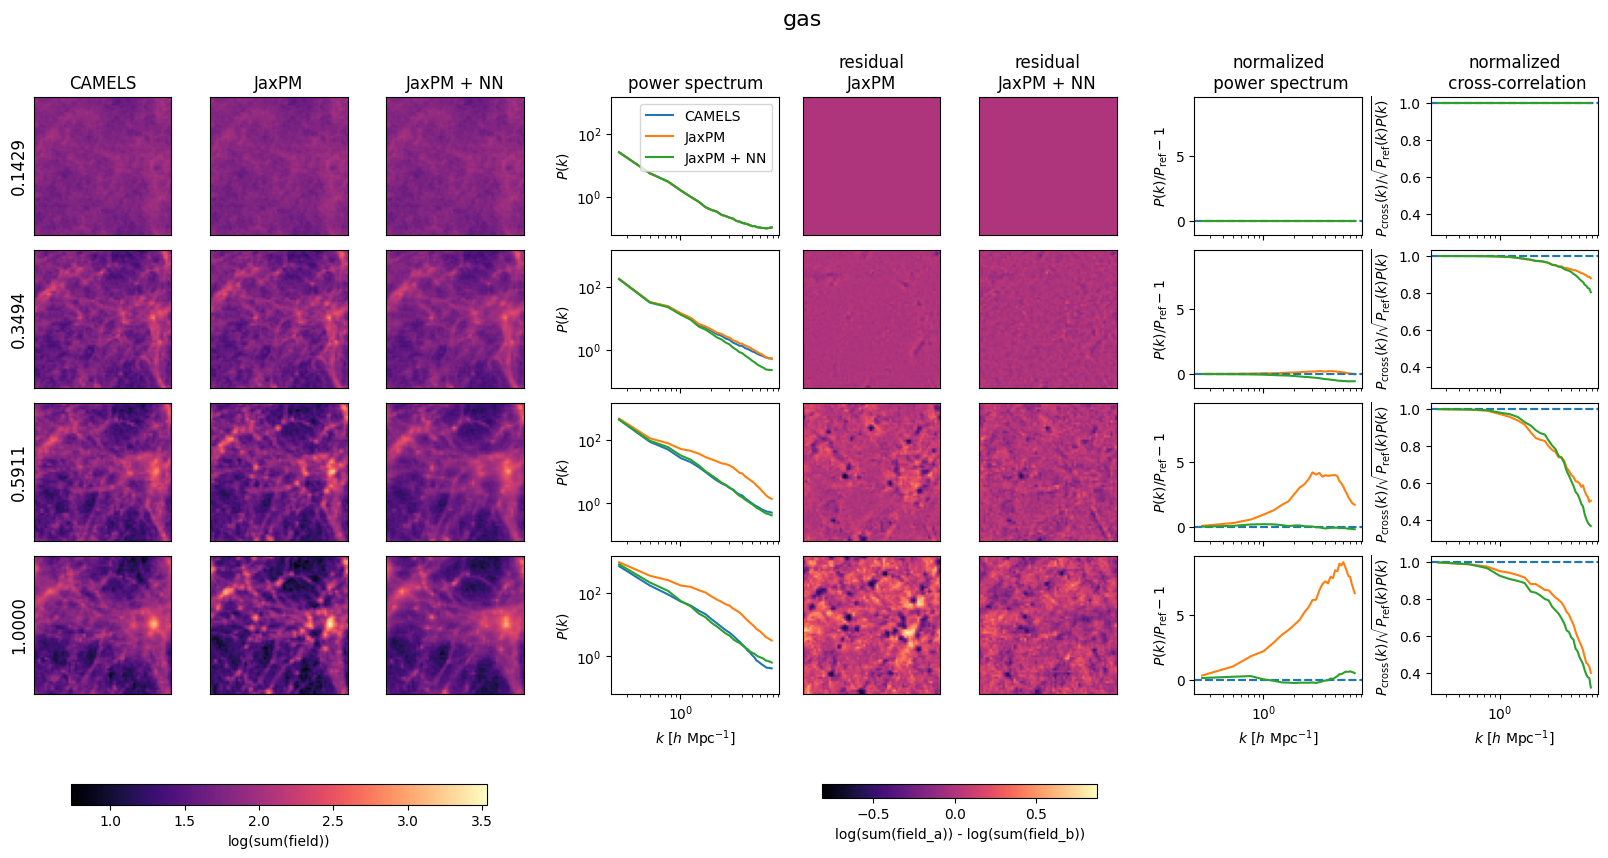

In [45]:
i_plot = np.linspace(0, len(scales) - 1, 4, dtype=int)
diagnostics.run_simulations(
    train_dict,
    mesh_per_dim,
    # gravity_model=gravity_model,
    pressure_model=pressure_model, 
    i_init=i0,
    i_plot=i_plot,
    nt=1,
    plot_gas=True,
)

In [25]:
i0 = 0
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])

t0 = scales[i0]
tsave = scales
tstep = scales[i0:]
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)

pm_res = solve_ode(
    y0, t0, tsave, pressure_model=None, training=False, nt=1, tstep=tstep
)
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res

hpm_res = solve_ode(
    y0, t0, tsave, pressure_model=pressure_model, training=False, nt=1, tstep=tstep
)
hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res

Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 67 steps (StepTo with 1 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


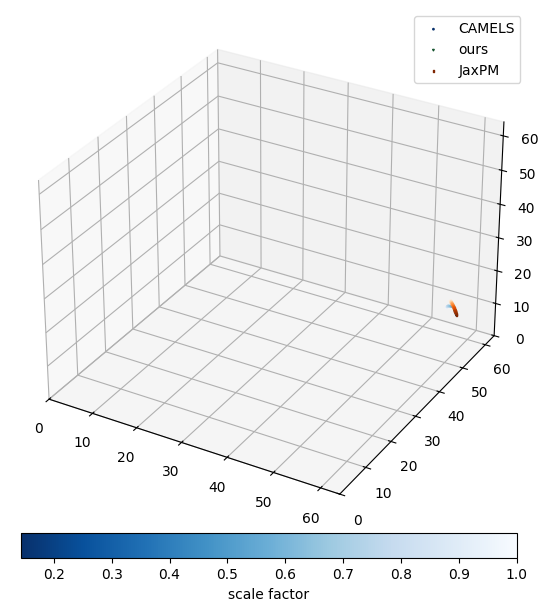

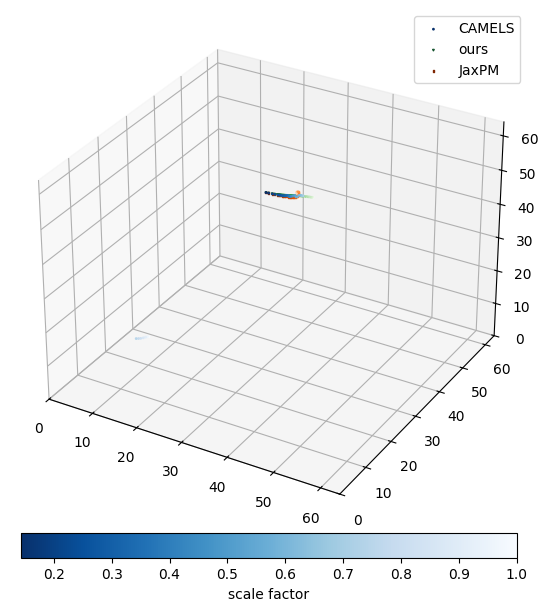

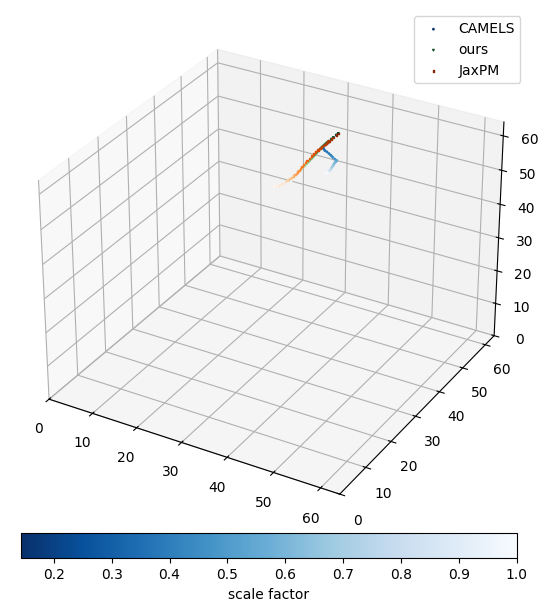

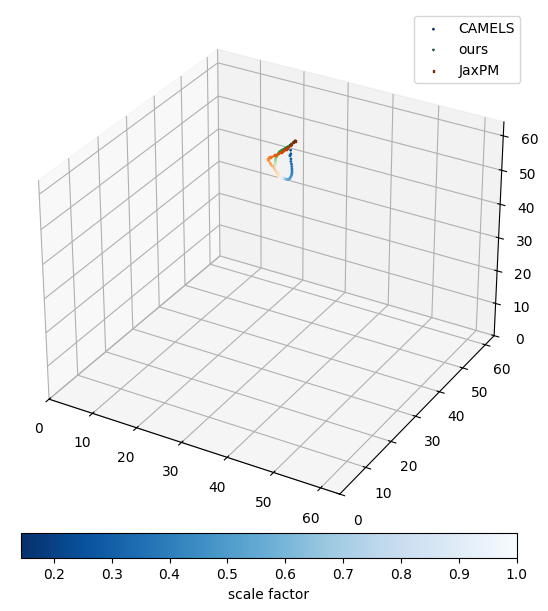

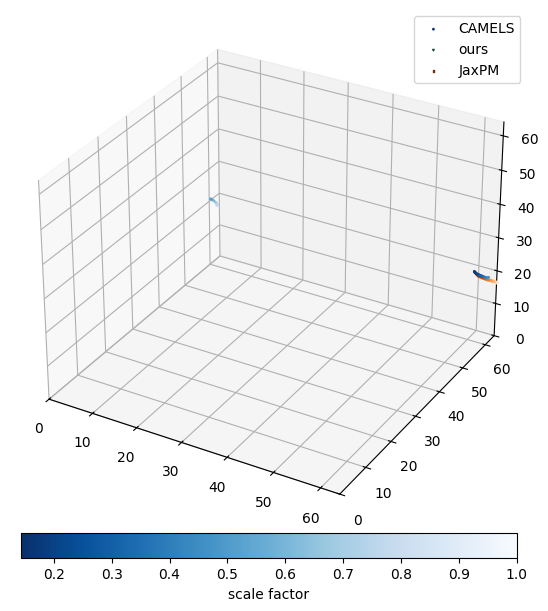

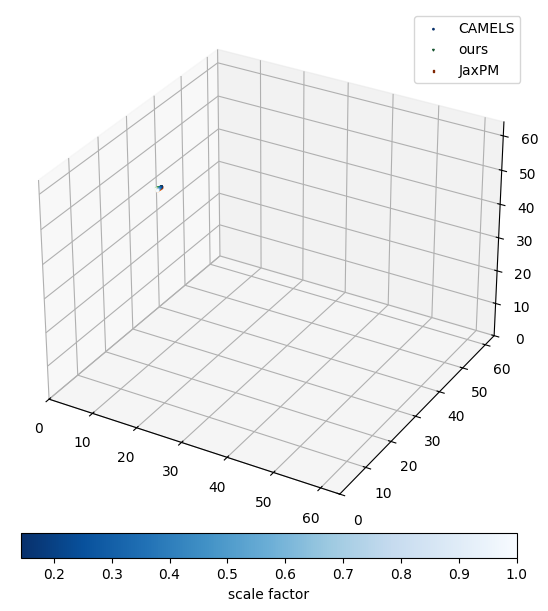

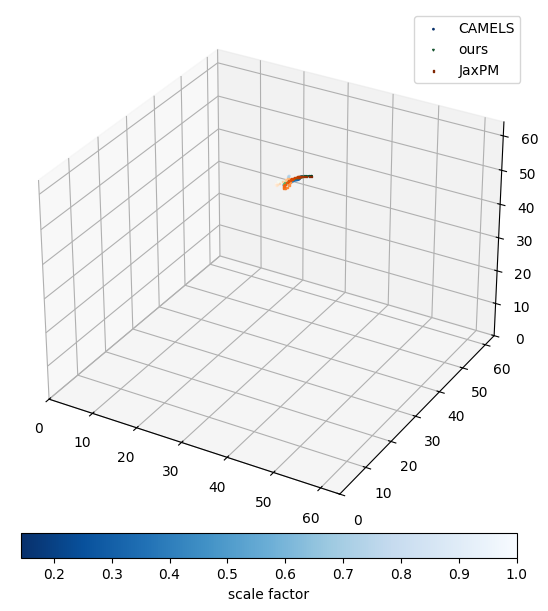

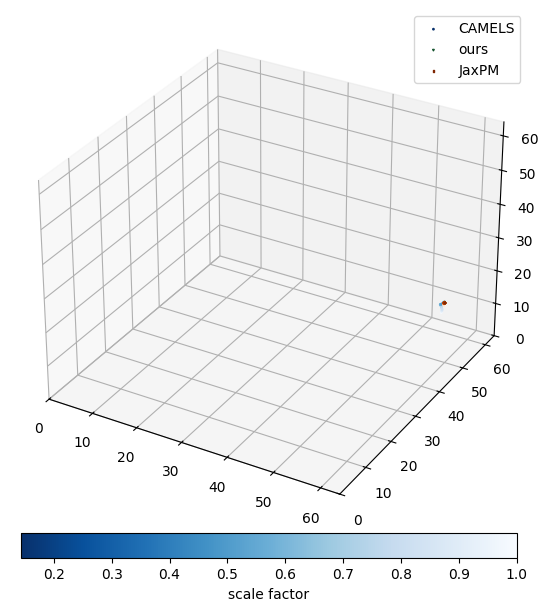

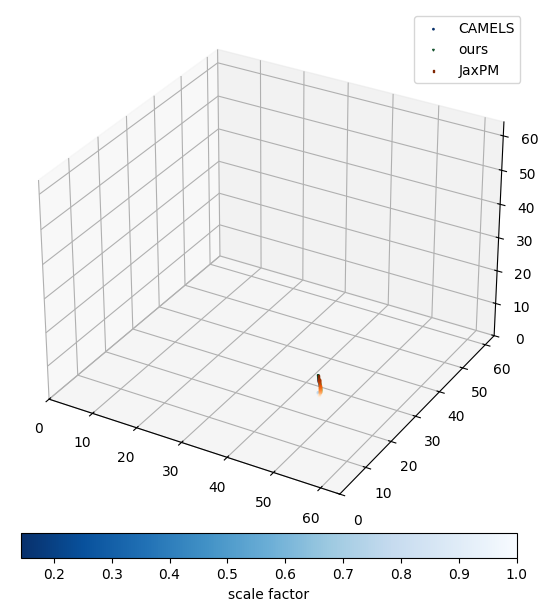

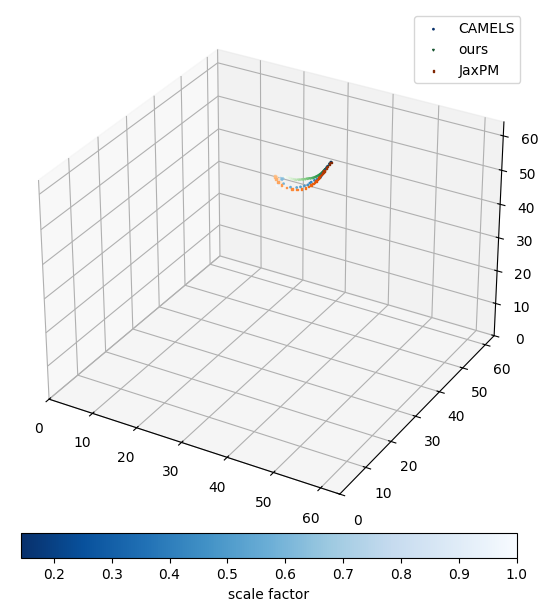

In [48]:
n_plots = 10

def get_coords(poss, i_rand):
    X = poss[:, i_rand, 0]
    Y = poss[:, i_rand, 1]
    Z = poss[:, i_rand, 2]

    return X, Y, Z

marker_size = 1
for i in range(n_plots):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    i_rand = np.random.choice(np.arange(parts_per_dim**3))
    im = ax.scatter(*get_coords(gas_poss, i_rand), c=scales, cmap="Blues_r", marker="o", alpha=1, s=marker_size, label="CAMELS")
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, aspect=20, label="scale factor", pad=0.01)
    im = ax.scatter(*get_coords(hpm_gas_poss, i_rand), c=scales, cmap="Greens_r", marker="v", alpha=1, s=marker_size, label="ours")
    im = ax.scatter(*get_coords(pm_gas_poss, i_rand), c=scales, cmap="Oranges_r", marker="s", alpha=1, s=marker_size, label="JaxPM")

    ax.legend()

    ax.set(xlim=(0,mesh_per_dim), ylim=(0,mesh_per_dim), zlim=(0,mesh_per_dim))

    fig.savefig(f"plots/trajectories_{i}.png", bbox_inches="tight", dpi=100)